<a href="https://colab.research.google.com/github/akuntugasrapon/RafkiAhmadPagamanda_2311533016_ML2526/blob/main/Praktikum1/Dataset_California_Housing_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LATIHAN 4

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

STEP 1 — Load Dataset

In [17]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


STEP 2 — Pisahkan Variabel

In [9]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

STEP 3 — Train Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

STEP 4 — Scaling [0,1]

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

STEP 5 — Train Model

In [12]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Intercept:", lr_model.intercept_)
print("Coefficients:", lr_model.coef_)

Intercept: 3.721516132506502
Coefficients: [  6.39513914   0.49408893 -14.78075919  20.98391128  -0.2003207
  -4.08551937  -3.98214561  -4.37460957]


STEP 6 — Evaluasi (MSE & R2)

In [13]:
from sklearn.metrics import mean_squared_error

y_pred = lr_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = lr_model.score(X_test, y_test)

print("MSE:", mse)
print("R2:", r2)

MSE: 0.5296293151408232
R2: 0.597142973735963


In [14]:
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.7277563569910078
MAE: 0.5352476763196584


STEP 7 — Plot Prediksi vs Aktual

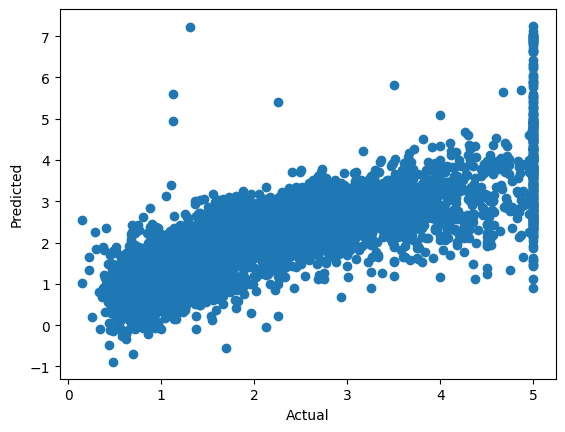

In [15]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

STEP 8 — Simpan Model

import pickle

filename = "finalized_model.sav"
pickle.dump(lr_model, open(filename, 'wb'))